# LSTM behavior analysis (XAI)

This notebook:
1. Computes **SHAP** and **LIME** feature importance
2. Computes **Integrated Gradients (IG)** memory horizon

Outputs → outputs/behaviors/{hourly,15min}/


In [1]:
TRACKS = ["hourly", "15min"]
STACKS = ["single", "double", "bidir"]
WINDOWS = {
    "hourly": [1, 4, 8, 12, 16, 24, 36, 48, 74, 168, 336, 672],
    "15min": [1, 4, 8, 16, 24, 48, 64, 96, 672],
}

In [2]:
test_ratio = 0.18

## Setup (Colab)

In [3]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn tensorflow shap lime scipy

from google.colab import drive
drive.mount("/content/drive")
BASE = "/content/drive/MyDrive/Shared-Colab-Storage/research"

print("BASE:", BASE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE: /content/drive/MyDrive/Shared-Colab-Storage/research


In [4]:
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import tensorflow as tf
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model

In [5]:
def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_true - y_pred)))


def build_windows(scaled_df, feature_cols, window, test_ratio=0.18):
    arr = scaled_df[feature_cols].to_numpy(dtype=np.float32)
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i + window])
        y.append(arr[i + window, 0])
    X, y = np.array(X), np.array(y)
    split = int(len(X) * (1 - test_ratio))
    return X[:split], X[split:], y[:split], y[split:]


def to_kwh(vals, scaler, n_features, target_idx=0):
    vals = np.asarray(vals).ravel()
    d = np.zeros((len(vals), n_features))
    d[:, target_idx] = vals
    return scaler.inverse_transform(d)[:, target_idx]


def integrated_gradients(model, x, baseline, steps=50):
    x_t = tf.convert_to_tensor(x[np.newaxis, ...], dtype=tf.float32)
    b_t = tf.convert_to_tensor(baseline[np.newaxis, ...], dtype=tf.float32)
    grads_sum = tf.zeros_like(x_t)
    for alpha in tf.linspace(0.0, 1.0, steps + 1):
        with tf.GradientTape() as tape:
            interp = b_t + alpha * (x_t - b_t)
            tape.watch(interp)
            pred = model(interp, training=False)
        grads_sum += tape.gradient(pred, interp)
    return ((x_t - b_t) * (grads_sum / float(steps + 1))).numpy()[0]


def track_paths(track):
    preprocess = os.path.join(BASE, "outputs", "preprocess", track)
    train = os.path.join(BASE, "outputs", "train", track)
    behaviors = os.path.join(BASE, "outputs", "behaviors", track)
    return {
        "preprocess": preprocess,
        "train": train,
        "behaviors": behaviors,
        "data_csv": os.path.join(preprocess, "data.csv"),
        "scaler_pkl": os.path.join(preprocess, "scaler.pkl"),
        "metrics_csv": os.path.join(train, "results_metrics.csv"),
    }


def model_path(train_root, stack, window):
    return os.path.join(train_root, stack, "models", f"win{window}.keras")

## Load preprocessed data

Reuse `data.csv` and `scaler.pkl` from preprocess, and trained models from `outputs/train/`

In [33]:
track_data = {}

for track in TRACKS:
    paths = track_paths(track)
    if not os.path.exists(paths["data_csv"]):
        print(f"Skip {track}: run preprocess.ipynb first")
        continue
    scaled_df = pd.read_csv(paths["data_csv"])
    with open(paths["scaler_pkl"], "rb") as f:
        scaler = pickle.load(f)
    feature_cols = list(scaled_df.columns)
    os.makedirs(paths["behaviors"], exist_ok=True)
    track_data[track] = {
        "paths": paths,
        "scaled_df": scaled_df,
        "scaler": scaler,
        "feature_cols": feature_cols,
    }
    print(track, "loaded:", scaled_df.shape, "features:", feature_cols)

hourly loaded: (8760, 9) features: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour_sin', 'hour_cos']
15min loaded: (35040, 9) features: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour_sin', 'hour_cos']


---
# Part 1 - SHAP (feature importance)

Which input features matter most for the prediction?

SHAP measures how much each feature changes the output.

In [ ]:
for track, info in track_data.items():
    paths = info["paths"]
    scaled_df = info["scaled_df"]
    feature_cols = info["feature_cols"]
    out_root = os.path.join(paths["behaviors"], "shap")

    for stack in STACKS:
        for window in WINDOWS[track]:
            mpath = model_path(paths["train"], stack, window)
            if not os.path.exists(mpath):
                continue

            os.makedirs(os.path.join(out_root, stack), exist_ok=True)
            shap_csv = os.path.join(out_root, stack, f"win{window}.csv")
            shap_png = os.path.join(out_root, stack, f"win{window}.png")
            if os.path.exists(shap_csv) and os.path.exists(shap_png) :
                print(f"exists: {track} {stack} win{window} shap")
                continue

            print(f"SHAP {track} {stack} win{window}...")
            model = load_model(mpath, custom_objects={"rmse": rmse})
            X_train, X_test, _, _ = build_windows(scaled_df, feature_cols, window, test_ratio)
            w, nf = window, X_train.shape[2]

            bg = X_train[:100].reshape(100, w * nf)
            test_flat = X_test[:30].reshape(30, w * nf)
            explainer = shap.KernelExplainer(
                lambda x: model.predict(x.reshape(-1, w, nf), verbose=0).ravel(), bg)
            sv = explainer.shap_values(test_flat, nsamples=40)
            labels = [f"t-{w - 1 - t}_{feature_cols[f]}" for t in range(w) for f in range(nf)]
            shap_df = pd.DataFrame({"feature": labels, "val": np.abs(sv).mean(0)})
            shap_df["attr"] = shap_df["feature"].str.replace(r"^t-\d+_", "", regex=True)
            rank = shap_df.groupby("attr")["val"].sum().sort_values(ascending=False).reset_index()
            rank.columns = ["attr", "value"]
            rank.to_csv(shap_csv, index=False)

            top = rank.head(8)
            plt.figure(figsize=(7, 4))
            plt.barh(top["attr"], top["value"])
            plt.gca().invert_yaxis()
            plt.xlabel("SHAP importance")
            plt.title(f"{track} {stack} win{window}")
            plt.tight_layout()
            plt.savefig(shap_png, dpi=120)
            plt.close()

exists: hourly single win1 shap
exists: hourly single win4 shap
exists: hourly single win8 shap
exists: hourly single win12 shap
exists: hourly single win16 shap
exists: hourly single win24 shap
exists: hourly single win36 shap
exists: hourly single win48 shap
exists: hourly single win74 shap
exists: hourly single win168 shap
exists: hourly single win336 shap
exists: hourly single win672 shap
exists: hourly double win1 shap
exists: hourly double win4 shap
exists: hourly double win8 shap
exists: hourly double win12 shap
exists: hourly double win16 shap
exists: hourly double win24 shap
exists: hourly double win36 shap
exists: hourly double win48 shap
exists: hourly double win74 shap
exists: hourly double win168 shap
exists: hourly double win336 shap
exists: hourly double win672 shap
exists: hourly bidir win1 shap
exists: hourly bidir win4 shap
exists: hourly bidir win8 shap
exists: hourly bidir win12 shap
exists: hourly bidir win16 shap
exists: hourly bidir win24 shap
exists: hourly bidi

---
# Part 2 — LIME + SHAP agreement (Spearman)

Do two different explainers agree on which features matter?

**Method:** LIME perturbs inputs locally; we rank features by mean |weight|. Then compare that ranking to Part 1 SHAP using **Spearman correlation** (1 = perfect agreement, 0 = unrelated).

**How to read:** High Spearman → both methods point at the same drivers. Low or negative → treat feature rankings cautiously.

In [6]:
LIME_TEST = 10
LIME_SAMPLES = 200

In [7]:
for track, info in track_data.items():
    paths = info["paths"]
    scaled_df = info["scaled_df"]
    feature_cols = info["feature_cols"]
    lime_root = os.path.join(paths["behaviors"], "lime")
    corr_root = os.path.join(paths["behaviors"], "shap_lime")

    for stack in STACKS:
        for window in WINDOWS[track]:
            mpath = model_path(paths["train"], stack, window)
            shap_csv = os.path.join(paths["behaviors"], "shap", stack, f"win{window}.csv")
            if not os.path.exists(mpath) or not os.path.exists(shap_csv):
                continue

            os.makedirs(os.path.join(lime_root, stack), exist_ok=True)
            os.makedirs(os.path.join(corr_root, stack), exist_ok=True)
            lime_csv = os.path.join(lime_root, stack, f"win{window}.csv")
            corr_csv = os.path.join(corr_root, stack, f"win{window}.csv")
            if os.path.exists(lime_csv) and os.path.exists(corr_csv) :
                print(f"exists: {track} {stack} win{window} lime")
                continue

            print(f"LIME {track} {stack} win{window}...")
            model = load_model(mpath, custom_objects={"rmse": rmse})
            X_train, X_test, _, _ = build_windows(scaled_df, feature_cols, window, test_ratio)
            w, nf = window, X_train.shape[2]

            if not os.path.exists(lime_csv):
                train_flat = X_train.reshape(len(X_train), w * nf)
                test_n = min(LIME_TEST, len(X_test))
                test_flat = X_test[:test_n].reshape(test_n, w * nf)
                lime_exp = LimeTabularExplainer(train_flat, mode="regression", verbose=False)
                importance = np.zeros(nf)
                for i in range(test_n):
                    exp = lime_exp.explain_instance(
                        test_flat[i],
                        lambda x: model.predict(x.reshape(-1, w, nf), verbose=0).ravel(),
                        num_samples=LIME_SAMPLES,
                        num_features=w * nf,
                    )
                    m = exp.as_map()
                    pairs = m.get(1) or m.get(0) or next(iter(m.values()))
                    for idx, wt in pairs:
                        importance[idx % nf] += abs(wt)
                lime_df = pd.DataFrame({"attr": feature_cols, "value": importance / max(test_n, 1)})
                lime_df = lime_df.sort_values("value", ascending=False)
                lime_df.to_csv(lime_csv, index=False)

            shap_rank = pd.read_csv(shap_csv).set_index("attr")
            lime_rank = pd.read_csv(lime_csv).set_index("attr")
            merged = shap_rank.join(lime_rank, lsuffix="_shap", rsuffix="_lime", how="inner")
            if len(merged) >= 2:
                corr, p = spearmanr(merged["value_shap"], merged["value_lime"])
            else:
                corr, p = np.nan, np.nan
            pd.DataFrame([{
                "track": track, "model": stack, "window": window,
                "spearman": corr, "p_value": p, "n_attrs": len(merged),
            }]).to_csv(corr_csv, index=False)
            print(f"  Spearman={corr:.3f}" if corr == corr else "  Spearman=nan")

exists: hourly single win1 lime
exists: hourly single win4 lime
exists: hourly single win8 lime
exists: hourly single win12 lime
exists: hourly single win16 lime
exists: hourly single win24 lime
exists: hourly single win36 lime
exists: hourly single win48 lime
exists: hourly single win74 lime
exists: hourly single win168 lime
exists: hourly single win336 lime
exists: hourly single win672 lime
exists: hourly double win1 lime
exists: hourly double win4 lime
exists: hourly double win8 lime
exists: hourly double win12 lime
exists: hourly double win16 lime
exists: hourly double win24 lime
exists: hourly double win36 lime
exists: hourly double win48 lime
exists: hourly double win74 lime
exists: hourly double win168 lime
exists: hourly double win336 lime
exists: hourly double win672 lime
exists: hourly bidir win1 lime
exists: hourly bidir win4 lime
exists: hourly bidir win8 lime
exists: hourly bidir win12 lime
exists: hourly bidir win16 lime
exists: hourly bidir win24 lime
exists: hourly bidi

---
# Part 3 - Integrated Gradients (memory horizon)

Which time steps in the input window does the LSTM use?

IG attributes the prediction to each step in the window.


In [8]:
IG_SAMPLES = 20

In [9]:
for track, info in track_data.items():
    paths = info["paths"]
    scaled_df = info["scaled_df"]
    feature_cols = info["feature_cols"]
    out_root = os.path.join(paths["behaviors"], "ig")

    for stack in STACKS:
        for window in WINDOWS[track]:
            mpath = model_path(paths["train"], stack, window)
            if not os.path.exists(mpath):
                continue

            os.makedirs(os.path.join(out_root, stack), exist_ok=True)
            csv_path = os.path.join(out_root, stack, f"win{window}.csv")
            png_path = os.path.join(out_root, stack, f"win{window}.png")
            if os.path.exists(csv_path) and os.path.exists(png_path) :
                print(f"exists: {track} {stack} win{window} ig")
                continue

            print(f"IG {track} {stack} win{window}...")
            model = load_model(mpath, custom_objects={"rmse": rmse})
            X_train, X_test, _, _ = build_windows(scaled_df, feature_cols, window, test_ratio)
            baseline = X_train.mean(axis=0)

            n = min(IG_SAMPLES, len(X_test))
            curves = []
            for i in range(n):
                attr = integrated_gradients(model, X_test[i], baseline)
                curves.append(np.abs(attr).mean(axis=1))
            horizon = np.mean(curves, axis=0)

            pd.DataFrame({"step": np.arange(window), "mean_abs_attr": horizon}).to_csv(csv_path, index=False)

            plt.figure(figsize=(8, 3))
            plt.plot(np.arange(window), horizon, "o-")
            plt.xlabel("Time step (0=oldest, right=recent)")
            plt.ylabel("Mean |attribution|")
            plt.title(f"{track} {stack} win{window} memory horizon")
            plt.tight_layout()
            plt.savefig(png_path, dpi=120)
            plt.close()

exists: hourly single win1 ig
exists: hourly single win4 ig
exists: hourly single win8 ig
exists: hourly single win12 ig
exists: hourly single win16 ig
exists: hourly single win24 ig
exists: hourly single win36 ig
exists: hourly single win48 ig
exists: hourly single win74 ig
exists: hourly single win168 ig
exists: hourly single win336 ig
exists: hourly single win672 ig
exists: hourly double win1 ig
exists: hourly double win4 ig
exists: hourly double win8 ig
exists: hourly double win12 ig
exists: hourly double win16 ig
exists: hourly double win24 ig
exists: hourly double win36 ig
exists: hourly double win48 ig
exists: hourly double win74 ig
exists: hourly double win168 ig
exists: hourly double win336 ig
exists: hourly double win672 ig
exists: hourly bidir win1 ig
exists: hourly bidir win4 ig
exists: hourly bidir win8 ig
exists: hourly bidir win12 ig
exists: hourly bidir win16 ig
exists: hourly bidir win24 ig
exists: hourly bidir win36 ig
exists: hourly bidir win48 ig
exists: hourly bidi

---
# Part 4 — Memory erasure

If we wipe old history, does prediction get worse?

Replace the oldest 0%, 25%, 50%, 75% of each window with the training mean, then measure RMSE.


In [34]:
ERASE_CUTOFFS = [0.0, 0.25, 0.5, 0.75]

In [35]:
for track, info in track_data.items():
    paths = info["paths"]
    scaled_df = info["scaled_df"]
    scaler = info["scaler"]
    feature_cols = info["feature_cols"]
    n_feat = len(feature_cols)
    out_root = os.path.join(paths["behaviors"], "erasure")

    for stack in STACKS:
        for window in WINDOWS[track]:
            mpath = model_path(paths["train"], stack, window)
            if not os.path.exists(mpath):
                continue

            os.makedirs(os.path.join(out_root, stack), exist_ok=True)
            csv_path = os.path.join(out_root, stack, f"win{window}.csv")
            png_path = os.path.join(out_root, stack, f"win{window}.png")
            if os.path.exists(csv_path) and os.path.exists(png_path) :
                print(f"exists: {track} {stack} win{window} erasure")
                continue

            print(f"Erasure {track} {stack} win{window}...")
            model = load_model(mpath, custom_objects={"rmse": rmse})
            X_train, X_test, _, y_test = build_windows(scaled_df, feature_cols, window, test_ratio)
            mean_window = X_train.mean(axis=0)
            yt = to_kwh(y_test, scaler, n_feat)

            rows = []
            for cutoff in ERASE_CUTOFFS:
                X_mod = X_test.copy()
                cut = int(window * cutoff)
                if cut > 0:
                    X_mod[:, :cut, :] = mean_window[:cut, :]
                yp = to_kwh(model.predict(X_mod, verbose=0).ravel(), scaler, n_feat)
                rmse_k = float(np.sqrt(mean_squared_error(yt, yp)))
                rows.append({"cutoff": cutoff, "rmse_kwh": rmse_k})

            df = pd.DataFrame(rows)
            df.to_csv(csv_path, index=False)

            plt.figure(figsize=(6, 3))
            plt.plot(df["cutoff"], df["rmse_kwh"], "o-")
            plt.xlabel("Fraction of oldest window erased")
            plt.ylabel("RMSE (kWh)")
            plt.title(f"{track} {stack} win{window}")
            plt.tight_layout()
            plt.savefig(png_path, dpi=120)
            plt.close()

exists: hourly single win1 erasure
exists: hourly single win4 erasure
exists: hourly single win8 erasure
exists: hourly single win12 erasure
exists: hourly single win16 erasure
exists: hourly single win24 erasure
exists: hourly single win36 erasure
exists: hourly single win48 erasure
exists: hourly single win74 erasure
exists: hourly single win168 erasure
exists: hourly single win336 erasure
exists: hourly single win672 erasure
exists: hourly double win1 erasure
exists: hourly double win4 erasure
exists: hourly double win8 erasure
exists: hourly double win12 erasure
exists: hourly double win16 erasure
exists: hourly double win24 erasure
exists: hourly double win36 erasure
exists: hourly double win48 erasure
exists: hourly double win74 erasure
exists: hourly double win168 erasure
exists: hourly double win336 erasure
exists: hourly double win672 erasure
exists: hourly bidir win1 erasure
exists: hourly bidir win4 erasure
exists: hourly bidir win8 erasure
exists: hourly bidir win12 erasure

---
# Part 5 — Fidelity test

XAI says feature X is important , if we break X, does error really increase?

Take top features from SHAP. Set that feature to 0 across the whole window on the test set. Compare RMSE before vs after.

In [12]:
FIDELITY_TOP_K = 5

In [21]:
for track, info in track_data.items():
    paths = info["paths"]
    scaled_df = info["scaled_df"]
    scaler = info["scaler"]
    feature_cols = info["feature_cols"]
    n_feat = len(feature_cols)
    out_root = os.path.join(paths["behaviors"], "fidelity")

    for stack in STACKS:
        for window in WINDOWS[track]:
            mpath = model_path(paths["train"], stack, window)
            shap_csv = os.path.join(paths["behaviors"], "shap", stack, f"win{window}.csv")
            if not os.path.exists(mpath) or not os.path.exists(shap_csv):
                continue

            os.makedirs(os.path.join(out_root, stack), exist_ok=True)
            csv_path = os.path.join(out_root, stack, f"win{window}.csv")
            png_path = os.path.join(out_root, stack, f"win{window}.png")
            if os.path.exists(csv_path) and os.path.exists(png_path):
                print(f"exists: {track} {stack} win{window} fidelity")
                continue

            print(f"Fidelity {track} {stack} win{window}...")
            top_attrs = pd.read_csv(shap_csv)["attr"].head(FIDELITY_TOP_K).tolist()
            model = load_model(mpath, custom_objects={"rmse": rmse})
            _, X_test, _, y_test = build_windows(scaled_df, feature_cols, window, test_ratio)
            yt = to_kwh(y_test, scaler, n_feat)
            base_rmse = float(np.sqrt(mean_squared_error(
                yt, to_kwh(model.predict(X_test, verbose=0).ravel(), scaler, n_feat))))

            rows = []
            for attr in top_attrs:
                if attr not in feature_cols:
                    continue
                idx = feature_cols.index(attr)
                X_zero = X_test.copy()
                X_zero[:, :, idx] = 0.0
                rmse_zero = float(np.sqrt(mean_squared_error(
                    yt, to_kwh(model.predict(X_zero, verbose=0).ravel(), scaler, n_feat))))
                rows.append({
                    "attr": attr,
                    "baseline_rmse": base_rmse,
                    "rmse_zero": rmse_zero,
                    "delta": rmse_zero - base_rmse,
                })

            if not rows:
                continue
            df = pd.DataFrame(rows)
            df.to_csv(csv_path, index=False)

            plt.figure(figsize=(6, 3))
            x = np.arange(len(df))
            plt.bar(x - 0.15, [base_rmse] * len(df), width=0.3, label="baseline")
            plt.bar(x + 0.15, df["rmse_zero"], width=0.3, label="after zeroing")
            plt.xticks(x, df["attr"], rotation=30, ha="right")
            plt.ylabel("RMSE (kWh)")
            plt.title(f"{track} {stack} win{window} fidelity")
            plt.legend()
            plt.tight_layout()
            plt.savefig(png_path, dpi=120)
            plt.show()
            plt.close()

exists: hourly single win1 fidelity
exists: hourly single win4 fidelity
exists: hourly single win8 fidelity
exists: hourly single win12 fidelity
exists: hourly single win16 fidelity
exists: hourly single win24 fidelity
exists: hourly single win36 fidelity
exists: hourly single win48 fidelity
exists: hourly single win74 fidelity
exists: hourly single win168 fidelity
exists: hourly single win336 fidelity
exists: hourly single win672 fidelity
exists: hourly double win1 fidelity
exists: hourly double win4 fidelity
exists: hourly double win8 fidelity
exists: hourly double win12 fidelity
exists: hourly double win16 fidelity
exists: hourly double win24 fidelity
exists: hourly double win36 fidelity
exists: hourly double win48 fidelity
exists: hourly double win74 fidelity
exists: hourly double win168 fidelity
exists: hourly double win336 fidelity
exists: hourly double win672 fidelity
exists: hourly bidir win1 fidelity
exists: hourly bidir win4 fidelity
exists: hourly bidir win8 fidelity
exists:

---
# Part 6 — Compare architectures

Do single, double, and bidirectional LSTM behave differently at the same window size?


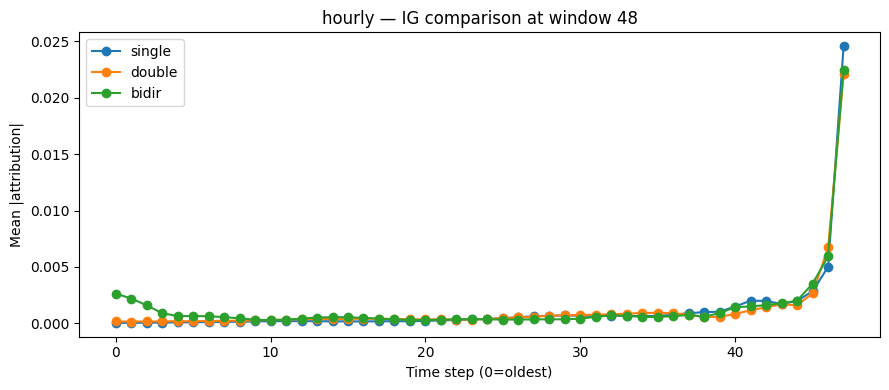

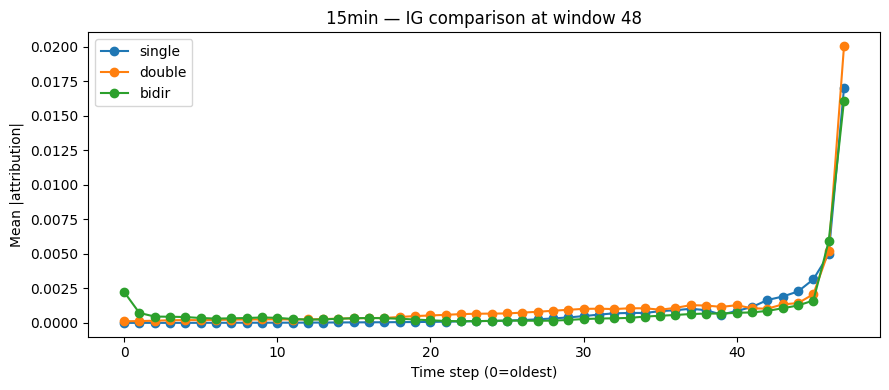

In [36]:
for track, info in track_data.items():
    paths = info["paths"]
    window = 48
    if window not in WINDOWS[track]:
        print(f"Skip compare for {track}: win{window} not in window list")
        continue

    plt.figure(figsize=(9, 4))
    found = 0
    for stack in STACKS:
        csv_path = os.path.join(paths["behaviors"], "ig", stack, f"win{window}.csv")
        if not os.path.exists(csv_path):
            continue
        d = pd.read_csv(csv_path)
        plt.plot(d["step"], d["mean_abs_attr"], "o-", label=stack)
        found += 1

    if found == 0:
        plt.close()
        print(f"No IG files for {track} win{window} — run Part 3 first")
        continue

    plt.xlabel("Time step (0=oldest)")
    plt.ylabel("Mean |attribution|")
    plt.title(f"{track} — IG comparison at window {window}")
    plt.legend()
    plt.tight_layout()
    out = os.path.join(paths["behaviors"], f"compare_ig_win{window}.png")
    plt.savefig(out, dpi=120)
    plt.show() 

---
## Done


| Folder / file | Contents |
|---------------|----------|
| `shap/` | Feature importance CSV + bar chart per model |
| `lime/` | LIME feature importance CSV per model  |
| `ig/` | Memory horizon CSV + line plot per model |
| `erasure/` | Memory erasure CSV + line plot per model |
| `fidelity/` | Fidelity CSV + bar chart per model |
| `compare_ig_win24.png` | Single vs double vs bidir overlay |
